In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import os

In [3]:
os.makedirs('./results/eda_visualizations', exist_ok=True)

In [4]:
df_raw = pd.read_csv('warsaw.csv')

In [5]:
df_clean = df_raw.drop(columns=['STATION', 'NAME', 'LATITUDE', 'LONGITUDE', 'ELEVATION']).copy()

In [6]:
df_clean['PRCP'] = df_clean['PRCP'].fillna(0.0)
df_clean['SNWD'] = df_clean['SNWD'].fillna(0.0)
df_clean['TMAX'] = df_clean['TMAX'].fillna(df_clean['TAVG'] + 4.8)
df_clean['TMIN'] = df_clean['TMIN'].fillna(df_clean['TAVG'] - 4.4)

In [7]:
df_clean['DATE'] = pd.to_datetime(df_clean['DATE'])
df_clean['Year'] = df_clean['DATE'].dt.year
df_clean['Month'] = df_clean['DATE'].dt.month
df_clean['Day'] = df_clean['DATE'].dt.day

In [8]:
scaler = StandardScaler()

In [9]:
features_to_scale = ['PRCP', 'SNWD', 'TMAX', 'TMIN', 'TAVG'] 
df_clean[features_to_scale] = scaler.fit_transform(df_clean[features_to_scale])

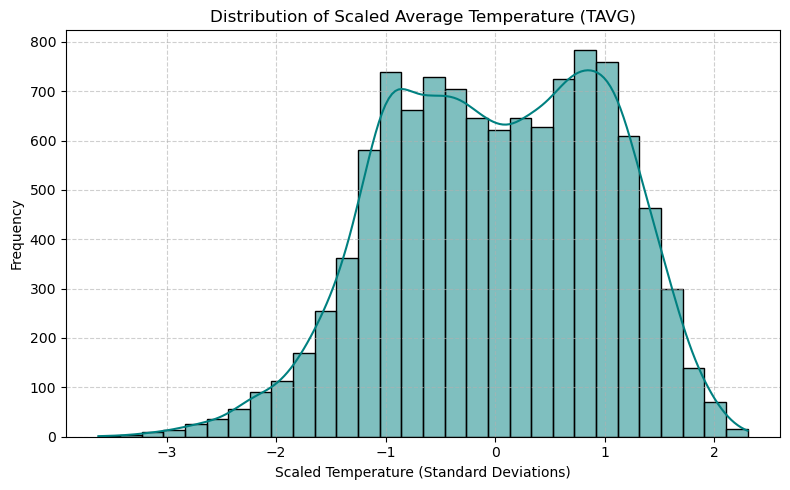

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['TAVG'], kde=True, color='teal', bins=30)
plt.title('Distribution of Scaled Average Temperature (TAVG)')
plt.xlabel('Scaled Temperature (Standard Deviations)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('results/eda_visualizations/1_tavg_histogram.png')
plt.show()

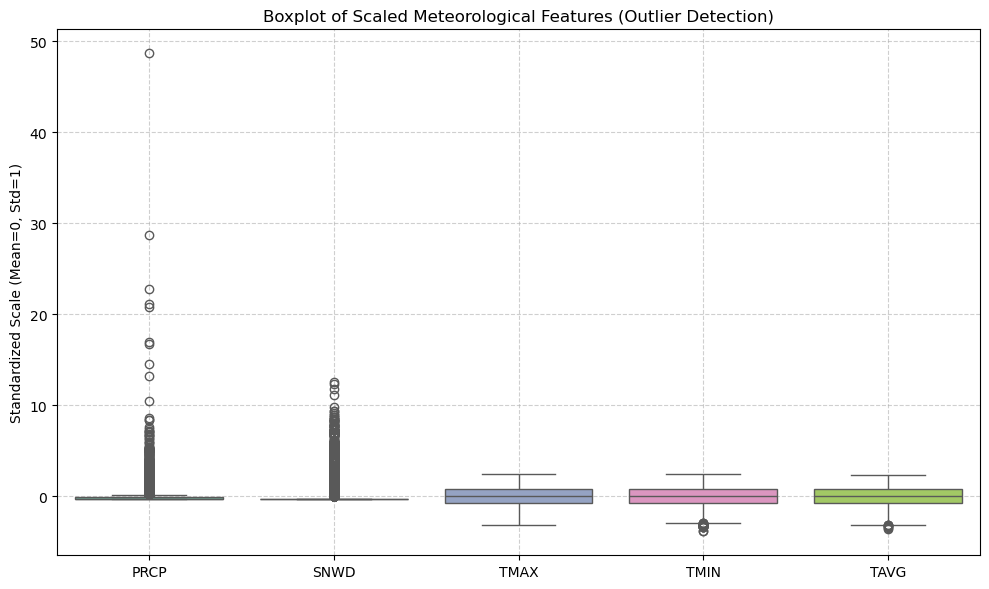

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean[features_to_scale], palette='Set2')
plt.title('Boxplot of Scaled Meteorological Features (Outlier Detection)')
plt.ylabel('Standardized Scale (Mean=0, Std=1)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('results/eda_visualizations/2_feature_boxplots.png')
plt.show()

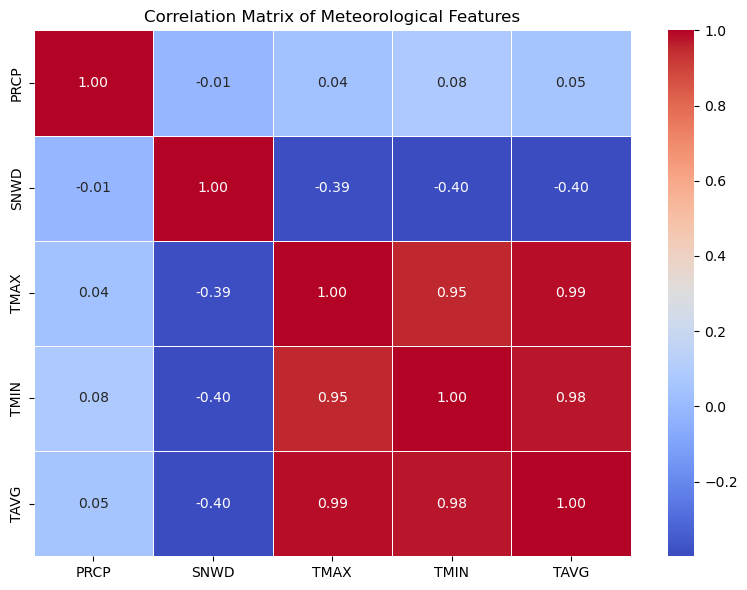

In [13]:
plt.figure(figsize=(8, 6))
correlation_matrix = df_clean[features_to_scale].corr()
sns.heatmap(
    correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5
)
plt.title('Correlation Matrix of Meteorological Features')
plt.tight_layout()
plt.savefig('results/eda_visualizations/3_correlation_matrix.png')
plt.show()

In [14]:
df_clean.to_csv('warsaw_processedfinal.csv', index=False)
print('Successfully saved processed data and all visualizations!')

Successfully saved processed data and all visualizations!
